<a href="https://colab.research.google.com/github/babi00/ai4biological-pattern/blob/clean-barbara/barbara_new/classificatore_specie_invasive_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classificatore specie:
- input: immagine
- output label: nativa/non nativa e non invasiva/non nativa e invasiva
La struttura del modello utilizzato è simile a quella precedentemente implementata:
le immagini passano attraverso un modello preallenato (BioCLIP o ResNet) da cui vengono estratti gli embedding
gli embedding allenano un semplice classificatore.

Durante il training le fasi di estrazione degli embedding e predizione del label sono separate (così che il training sia molto più veloce e leggero). Una volta finito il training viene ricostruito il modello intero, così che il classificatore prenda come input l'immagine (non l'embedding) e restituisca il label (in modo che si possa effettuare successivamente explainability sulle immagini e non solo sugli embedding).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix, ConfusionMatrixDisplay, f1_score
import seaborn as sns
import requests
from io import BytesIO
from google.colab import drive
import time
from tqdm import tqdm
!pip install open_clip_torch
import open_clip
import random
import math

torch.manual_seed(42)
np.random.seed(42)

drive.mount('/content/drive')

# Clone the repository and checkout the 'clean-barbara' branch
!git clone --branch clean-barbara https://github.com/babi00/ai4biological-pattern.git
%cd ai4biological-pattern

# Enable sparse checkout
!git sparse-checkout init --cone

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'ai4biological-pattern' already exists and is not an empty directory.
/content/ai4biological-pattern


In [2]:
#new version: trying to save memory..
class InvasiveSpeciesDataset(Dataset):
    def __init__(self, root_dir, transform=None, get_label_fn=None):
        self.root_dir = root_dir
        self.transform = transform
        self.entries = []
        self.label_map = {
            "native": 0,
            "introduced non-invasive": 1,
            "invasive": 2
        }

        taxa_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d)) and d != "metadata"]
        for taxon in taxa_folders:
            meta_path = os.path.join(root_dir, "filtered_metadata", f"{taxon}_metadata.csv")
            if not os.path.exists(meta_path):
                continue
            metadata_df = pd.read_csv(meta_path)
            for idx, row in metadata_df.iterrows():
                self.entries.append((taxon, row))  # Just index, don’t open anything

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        taxon, row = self.entries[idx]
        filename = str(row["filename"])
        image_path = os.path.join(self.root_dir, taxon, filename)
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.label_map.get(row["label"])
        return image, label, idx

In [3]:
# Dummy version, replace this
def dummy_get_species_status(species_name, latitude, longitude):
    return random.choice([0, 1, 2])  # 0=native, 1=non-native non-invasive, 2=non-native invasive

In [4]:
def get_data_loader(root_dir, batch_size=32, use_bioclip=True, preprocess=None):
    if use_bioclip and preprocess:
        transform = preprocess
    else:
        transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor()
        ])

    dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        transform=transform,
    )

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_data, val_data = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

    return train_loader, val_loader

In [5]:
#2.Define the embedding extractor:
#ResNet without the last FC layer
def get_resnet_embeddings_extractor_model():
    #Use a pre-trained ResNet18 model
    model = models.resnet18(weights='IMAGENET1K_V1')

    #Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    embeddings_extractor= nn.Sequential(*list(model.children())[:-1]) #removes the last FC layer
    print("Model obtained...")

    return embeddings_extractor

#BioCLIP model
def get_bioclip_embeddings_extractor_model(device, bioclip_version=2):
    if bioclip_version==2:
        print("BioCLIP 2!")
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip-2')
    else:
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
    print("Model obtained...")
    model.to(device)
    model.eval()
    return model, preprocess

In [6]:
#3.Extract embeddings using the embeddings_extractor and create the DataLoader
def extract_embeddings(dataloader, embeddings_extractor, device, use_bioclip=True):
    embeddings_extractor.eval()
    all_embeddings = []
    all_labels = []
    all_ids = []

    if use_bioclip:
      with torch.no_grad():
        for images, labels, obs_id in dataloader:
            images = images.to(device)
            embeddings = embeddings_extractor.encode_image(images)
            embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)  # Optional: normalize
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_ids.extend(obs_id)

    else:
      with torch.no_grad():
        for images, labels, obs_id in dataloader:
            images = images.to(device)
            embeddings = embeddings_extractor(images).view(images.size(0), -1)
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_ids.extend(obs_id)

    embeddings_tensors = torch.cat(all_embeddings, dim=0).to(device)
    labels_tensors = torch.cat(all_labels, dim=0).to(device)
    obs_id_tensor = torch.tensor(all_ids).to(device)


    dataset = torch.utils.data.TensorDataset(embeddings_tensors, labels_tensors, obs_id_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

    embedding_size = embeddings_tensors.shape[1] #useful for classifier

    return loader, embedding_size

In [7]:
#Classifier
class InvasiveSpeciesClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=256, num_classes=3):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(), #consider adding a Dropout layer
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

In [8]:
#4. Training function
def train_classifier(train_loader, val_loader, feature_extractor, classifier, optimizer, criterion, device, output_dir, model_name, num_epoch=10):

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epoch):
        print(f"\n🔁 Epoch {epoch + 1}/{num_epoch}")
        classifier.train()
        running_loss, correct, total = 0, 0, 0

        for embeddings, labels, _ in tqdm(train_loader, desc="Training"): # Unpack all three values
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc, y_true, y_pred = evaluate_classifier(
            val_loader, feature_extractor, classifier, criterion, device
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"📉 Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
        print(f"📈 Val Loss:   {val_loss:.4f} | Accuracy: {val_acc:.4f}")

        print("\n📋 Classification Report:")
        print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=["Native", "NN Non-Invasive", "NN Invasive"], zero_division=0))

        #plot confuzion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.figure.colorbar(im, ax=ax)
        classes = ["Native", "NN-NI", "NN-I"]

        # Show all ticks and label them
        ax.set(xticks=np.arange(len(classes)),
              yticks=np.arange(len(classes)),
              xticklabels=classes,
              yticklabels=classes,
              ylabel='True label',
              xlabel='Predicted label',
              title='Validation Confusion Matrix')

        # Rotate the tick labels and set alignment.
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        # Loop over data dimensions and create text annotations.
        fmt = 'd'
        thresh = cm.max() / 2. if cm.max() > 0 else 1
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(cm[i, j], fmt),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")

        fig.tight_layout()
        plt.grid(False)
        plt.show()


    torch.save(classifier.state_dict(), f'classifier_head_{model_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/TESI - PoliTO/{output_dir}/classifier_head_{model_name}.pth'
    torch.save(classifier.state_dict(), google_drive_path)

    return train_losses, train_accuracies, val_losses, val_accuracies

In [9]:
#5. Evaluation function
def evaluate_classifier(loader, feature_extractor, classifier, criterion, device):
    classifier.eval()
    total_loss, correct, total = 0, 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for embeddings, labels, obs_ids in tqdm(loader, desc="Evaluating"): # Unpack all three values
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc, all_labels, all_preds

In [10]:
class FullModel(nn.Module):
    def __init__(self, embedding_model, classifier_head):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier_head = classifier_head

    def forward(self, x):
        with torch.no_grad():
            if hasattr(self.encoder, 'encode_image'):
                features = self.encoder.encode_image(x)
            else:
                features = self.encoder(x)

        if features.ndim == 4:
            features = features.view(features.size(0), -1)

        return self.classifier_head(features)

In [11]:
def create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=None, output_dir="invasive_species", model_name="prova"):
    start_time = time.time()

    model_name = f'bioclip_2_{model_name}' if use_bioclip and bioclip_version==2 else f'bioclip_1_{model_name}' if use_bioclip else f'resnet_{model_name}'

    github = '/content/ai4biological-pattern/barbara_new'
    github_repository = f'{github}/{folder_name}'

    if not os.path.isdir(github_repository): #check if data has already been downloaded
        !git sparse-checkout set barbara_new/{folder_name}
        !git checkout clean-barbara

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    if use_bioclip:
        feature_extractor, preprocess = get_bioclip_embeddings_extractor_model(device, bioclip_version)
        feature_extractor = feature_extractor.to(device)
    else:
        feature_extractor = get_resnet_embeddings_extractor_model()
        feature_extractor = feature_extractor.to(device)
        preprocess = None

    print("Feature extractor obtained..")
    train_loader, val_loader = get_data_loader(root_dir=github_repository)
    print("Dataloader obtained..")

    #extract embeddings and save in dataloaders
    embeddings_train_loader, input_size = extract_embeddings(train_loader, feature_extractor, device, use_bioclip)
    print("Train loader embeddings extracted..")
    embeddings_val_loader, _ = extract_embeddings(val_loader, feature_extractor, device, use_bioclip)
    print("Val loader embeddings extracted..")

    classifier = InvasiveSpeciesClassifier(embedding_dim=input_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=1e-4)


    train_losses, train_accuracies, val_losses, val_accuracies = train_classifier(
        train_loader=embeddings_train_loader,
        val_loader=embeddings_val_loader,
        feature_extractor=feature_extractor,
        classifier=classifier,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        output_dir=output_dir,
        model_name=model_name,
        num_epoch=10
    )

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Train Loss')
    plt.plot(epochs, val_losses, 'ro-', label='Val Loss')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'bo-', label='Train Accuracy')
    plt.plot(epochs, val_accuracies, 'ro-', label='Val Accuracy')
    plt.title("Accuracy over Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    full_model = FullModel(feature_extractor, classifier)
    print("Full model built...")
    full_model.eval()
    torch.save(full_model.state_dict(), f'full_{model_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/TESI - PoliTO/{output_dir}/full_{model_name}.pth'
    torch.save(full_model.state_dict(), google_drive_path)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total execution time: {elapsed_time:.2f} seconds")

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Model obtained...
Feature extractor obtained..
Dataloader obtained..
Train loader embeddings extracted..
Val loader embeddings extracted..

🔁 Epoch 1/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1102.28it/s]


📉 Train Loss: 0.6540 | Accuracy: 0.7114
📈 Val Loss:   0.5577 | Accuracy: 0.7286

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.92      0.83      6200
NN Non-Invasive       0.00      0.00      0.00       193
    NN Invasive       0.58      0.28      0.38      2403

       accuracy                           0.73      8796
      macro avg       0.44      0.40      0.40      8796
   weighted avg       0.69      0.73      0.69      8796



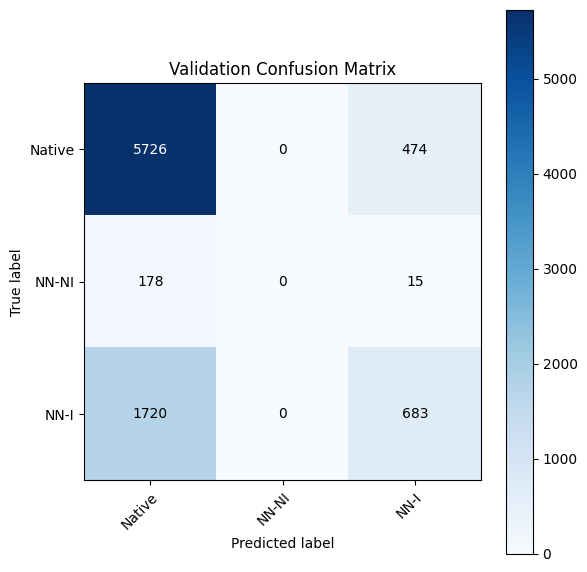


🔁 Epoch 2/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1090.24it/s]


📉 Train Loss: 0.5271 | Accuracy: 0.7502
📈 Val Loss:   0.5154 | Accuracy: 0.7576

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.80      0.89      0.84      6200
NN Non-Invasive       0.00      0.00      0.00       193
    NN Invasive       0.62      0.49      0.55      2403

       accuracy                           0.76      8796
      macro avg       0.47      0.46      0.46      8796
   weighted avg       0.73      0.76      0.74      8796



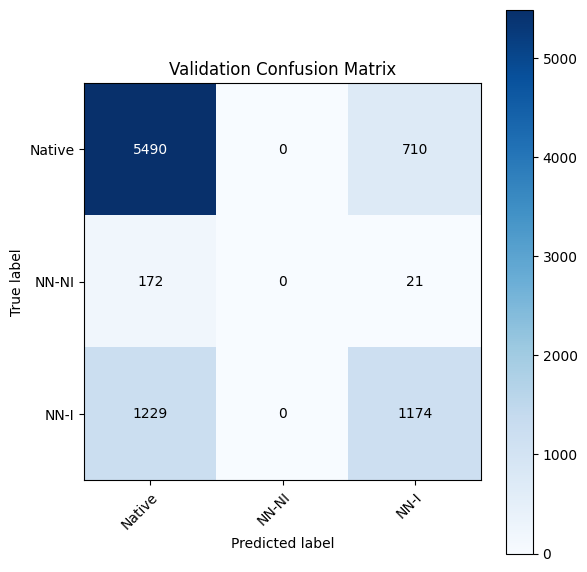


🔁 Epoch 3/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1091.78it/s]


📉 Train Loss: 0.4967 | Accuracy: 0.7654
📈 Val Loss:   0.4928 | Accuracy: 0.7690

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.80      0.90      0.85      6200
NN Non-Invasive       0.00      0.00      0.00       193
    NN Invasive       0.64      0.50      0.57      2403

       accuracy                           0.77      8796
      macro avg       0.48      0.47      0.47      8796
   weighted avg       0.74      0.77      0.75      8796



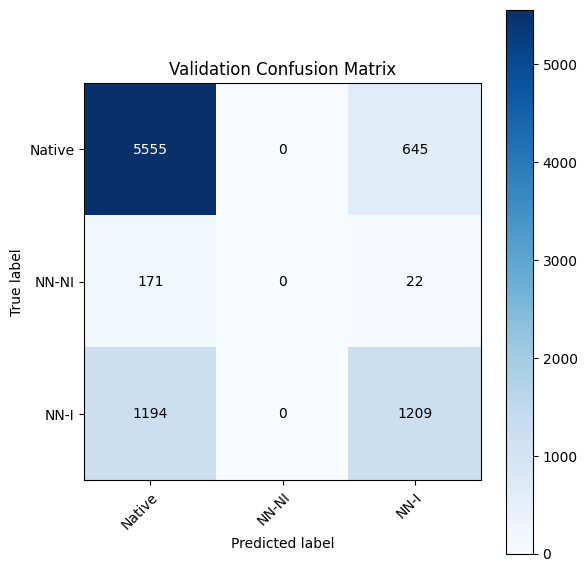


🔁 Epoch 4/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1106.84it/s]


📉 Train Loss: 0.4774 | Accuracy: 0.7766
📈 Val Loss:   0.4776 | Accuracy: 0.7761

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.80      0.91      0.85      6200
NN Non-Invasive       0.00      0.00      0.00       193
    NN Invasive       0.68      0.48      0.56      2403

       accuracy                           0.78      8796
      macro avg       0.49      0.47      0.47      8796
   weighted avg       0.75      0.78      0.76      8796



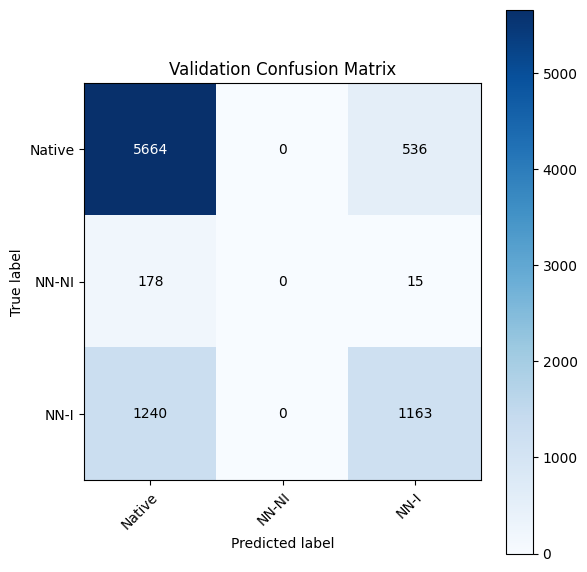


🔁 Epoch 5/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1003.87it/s]


📉 Train Loss: 0.4629 | Accuracy: 0.7817
📈 Val Loss:   0.4667 | Accuracy: 0.7800

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.80      0.92      0.86      6200
NN Non-Invasive       1.00      0.01      0.01       193
    NN Invasive       0.69      0.49      0.57      2403

       accuracy                           0.78      8796
      macro avg       0.83      0.47      0.48      8796
   weighted avg       0.78      0.78      0.76      8796



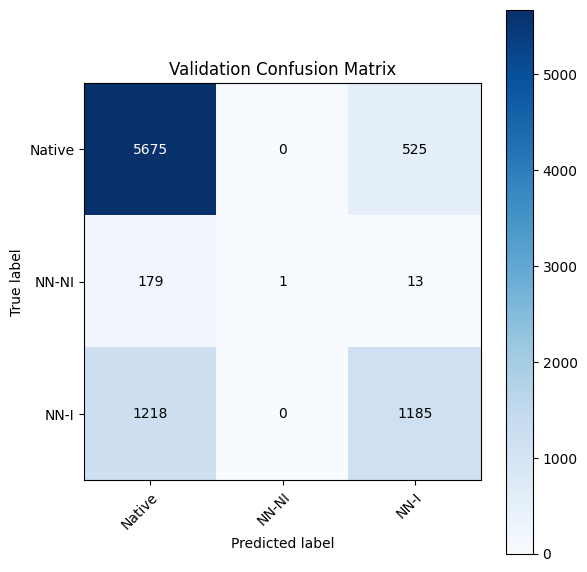


🔁 Epoch 6/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1040.83it/s]


📉 Train Loss: 0.4519 | Accuracy: 0.7868
📈 Val Loss:   0.4584 | Accuracy: 0.7866

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.83      0.88      0.85      6200
NN Non-Invasive       1.00      0.01      0.01       193
    NN Invasive       0.66      0.60      0.63      2403

       accuracy                           0.79      8796
      macro avg       0.83      0.50      0.50      8796
   weighted avg       0.79      0.79      0.77      8796



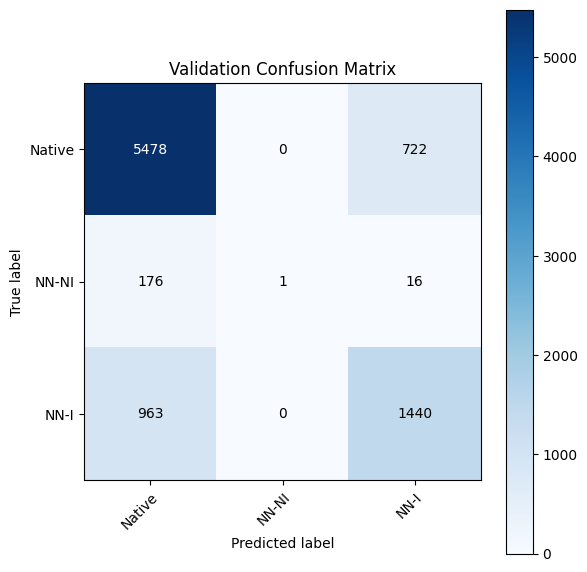


🔁 Epoch 7/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1077.63it/s]


📉 Train Loss: 0.4431 | Accuracy: 0.7914
📈 Val Loss:   0.4524 | Accuracy: 0.7873

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.81      0.91      0.86      6200
NN Non-Invasive       1.00      0.01      0.01       193
    NN Invasive       0.70      0.52      0.60      2403

       accuracy                           0.79      8796
      macro avg       0.84      0.48      0.49      8796
   weighted avg       0.78      0.79      0.77      8796



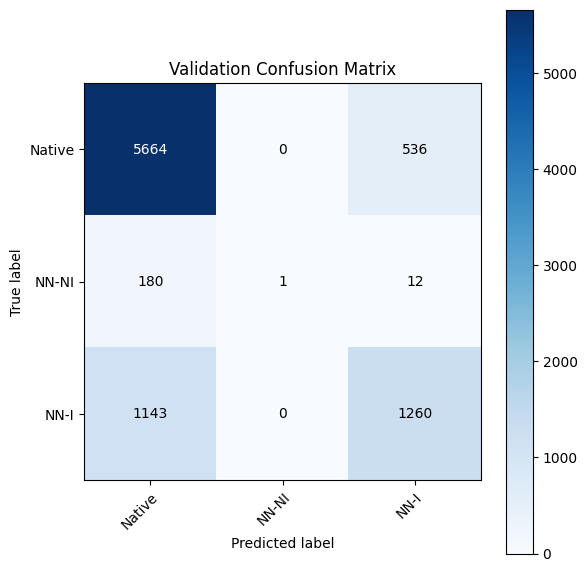


🔁 Epoch 8/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1102.11it/s]


📉 Train Loss: 0.4360 | Accuracy: 0.7951
📈 Val Loss:   0.4475 | Accuracy: 0.7925

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.88      0.86      6200
NN Non-Invasive       0.67      0.01      0.02       193
    NN Invasive       0.67      0.62      0.64      2403

       accuracy                           0.79      8796
      macro avg       0.72      0.51      0.51      8796
   weighted avg       0.79      0.79      0.78      8796



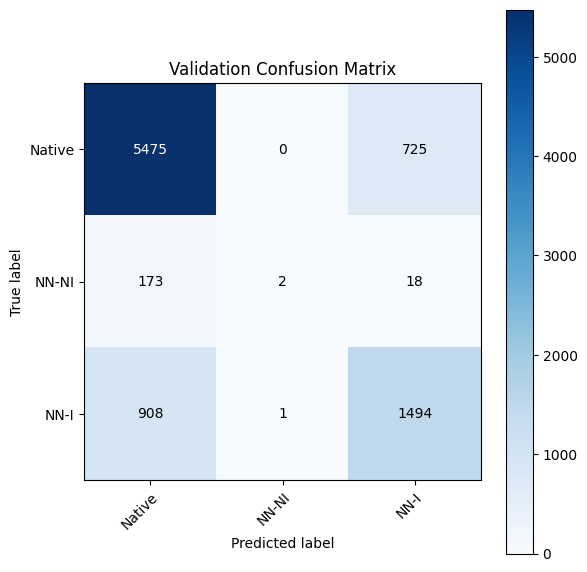


🔁 Epoch 9/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1090.15it/s]


📉 Train Loss: 0.4300 | Accuracy: 0.7974
📈 Val Loss:   0.4437 | Accuracy: 0.7929

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.83      0.89      0.86      6200
NN Non-Invasive       0.67      0.01      0.02       193
    NN Invasive       0.68      0.60      0.64      2403

       accuracy                           0.79      8796
      macro avg       0.73      0.50      0.51      8796
   weighted avg       0.78      0.79      0.78      8796



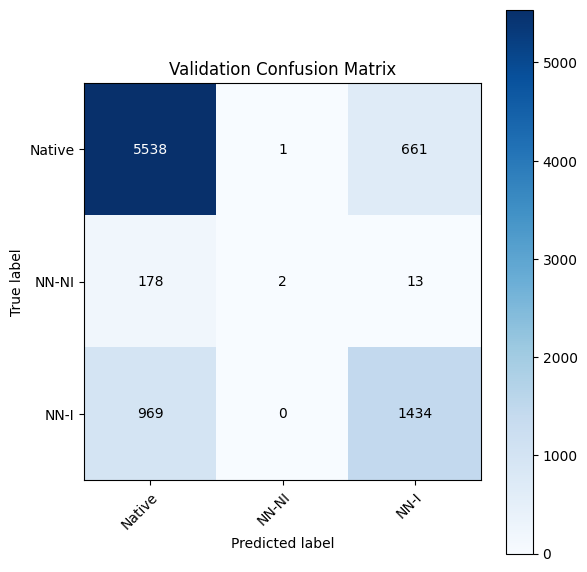


🔁 Epoch 10/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1086.55it/s]


📉 Train Loss: 0.4247 | Accuracy: 0.8013
📈 Val Loss:   0.4398 | Accuracy: 0.7958

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.82      0.91      0.86      6200
NN Non-Invasive       0.43      0.02      0.03       193
    NN Invasive       0.70      0.57      0.63      2403

       accuracy                           0.80      8796
      macro avg       0.65      0.50      0.51      8796
   weighted avg       0.78      0.80      0.78      8796



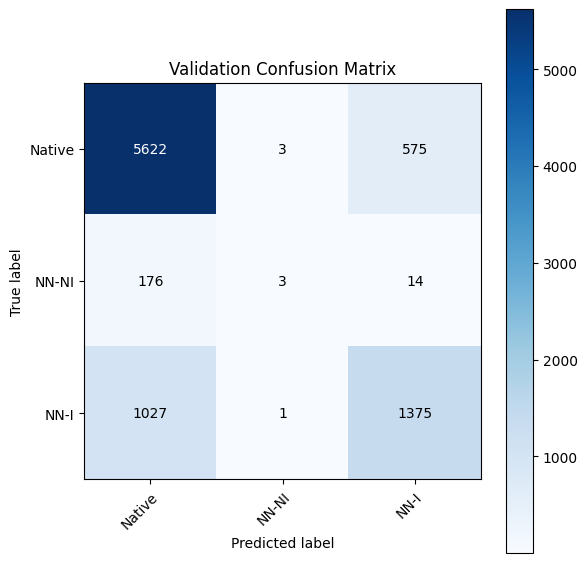

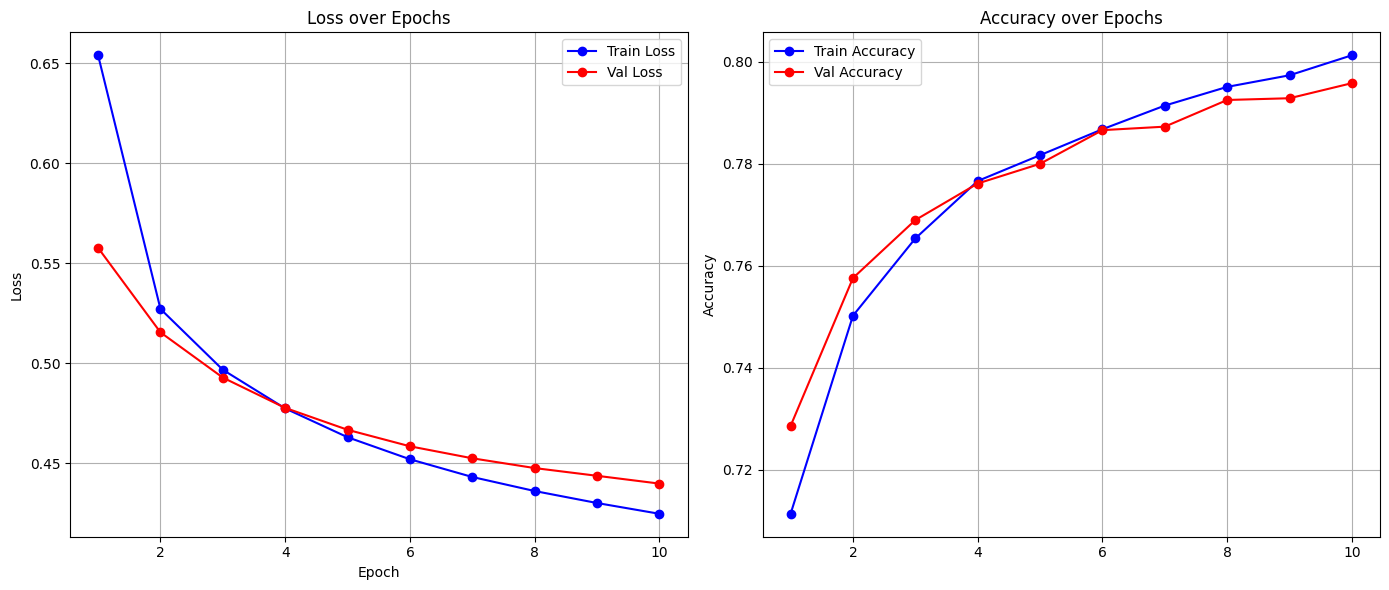

Full model built...
Total execution time: 686.72 seconds


In [12]:
create_model_and_predict(folder_name="taxas", use_bioclip=True, output_dir="invasive_species", model_name="first_attempt")

Using device: cuda


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 85.3MB/s]


Model obtained...
Feature extractor obtained..
Dataloader obtained..
Train loader embeddings extracted..
Val loader embeddings extracted..

🔁 Epoch 1/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1023.07it/s]


📉 Train Loss: 0.6501 | Accuracy: 0.7049
📈 Val Loss:   0.6079 | Accuracy: 0.7218

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.73      0.98      0.83      6274
NN Non-Invasive       0.00      0.00      0.00       163
    NN Invasive       0.61      0.08      0.14      2359

       accuracy                           0.72      8796
      macro avg       0.45      0.35      0.33      8796
   weighted avg       0.68      0.72      0.63      8796



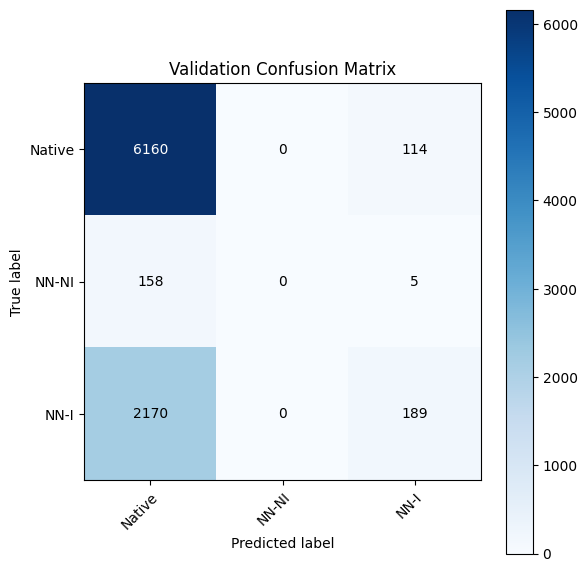


🔁 Epoch 2/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1098.19it/s]


📉 Train Loss: 0.6227 | Accuracy: 0.7114
📈 Val Loss:   0.5983 | Accuracy: 0.7244

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.93      0.83      6274
NN Non-Invasive       0.00      0.00      0.00       163
    NN Invasive       0.54      0.23      0.32      2359

       accuracy                           0.72      8796
      macro avg       0.43      0.39      0.38      8796
   weighted avg       0.68      0.72      0.68      8796



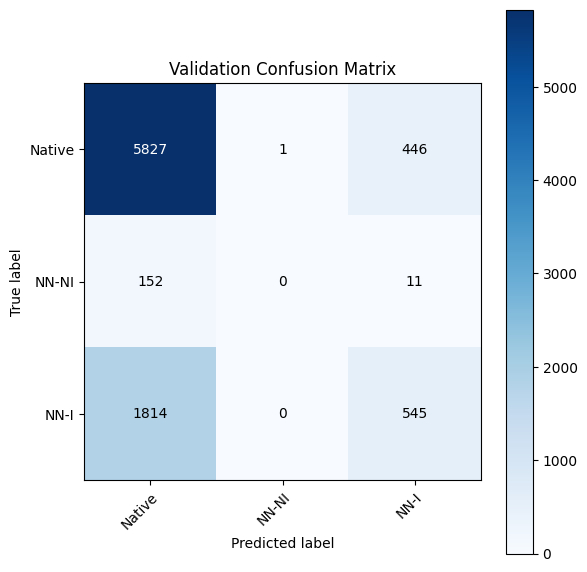


🔁 Epoch 3/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1113.24it/s]


📉 Train Loss: 0.6104 | Accuracy: 0.7164
📈 Val Loss:   0.5929 | Accuracy: 0.7287

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.74      0.96      0.84      6274
NN Non-Invasive       0.00      0.00      0.00       163
    NN Invasive       0.61      0.15      0.24      2359

       accuracy                           0.73      8796
      macro avg       0.45      0.37      0.36      8796
   weighted avg       0.69      0.73      0.66      8796



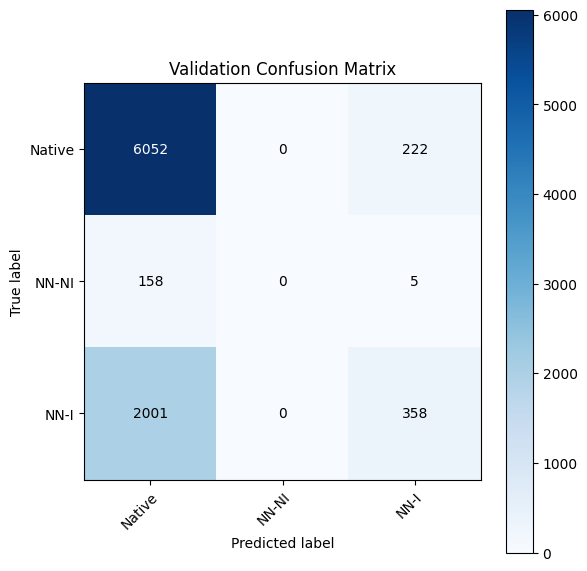


🔁 Epoch 4/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1107.35it/s]


📉 Train Loss: 0.5987 | Accuracy: 0.7202
📈 Val Loss:   0.5866 | Accuracy: 0.7275

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.74      0.94      0.83      6274
NN Non-Invasive       0.00      0.00      0.00       163
    NN Invasive       0.57      0.20      0.30      2359

       accuracy                           0.73      8796
      macro avg       0.44      0.38      0.38      8796
   weighted avg       0.68      0.73      0.67      8796



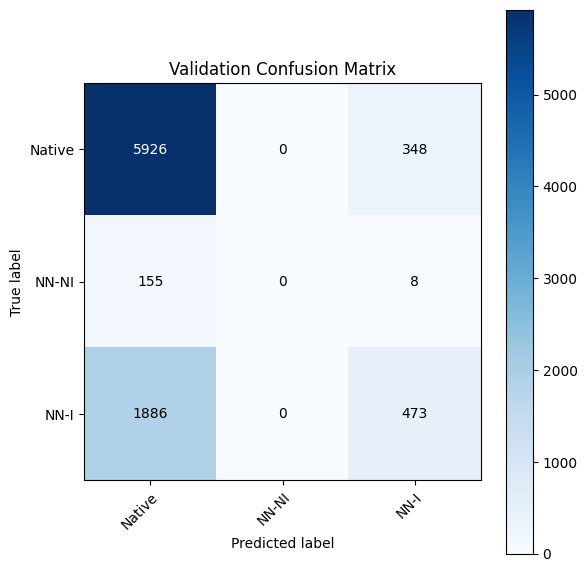


🔁 Epoch 5/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1104.61it/s]


📉 Train Loss: 0.5888 | Accuracy: 0.7279
📈 Val Loss:   0.5828 | Accuracy: 0.7300

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.93      0.83      6274
NN Non-Invasive       0.00      0.00      0.00       163
    NN Invasive       0.56      0.26      0.35      2359

       accuracy                           0.73      8796
      macro avg       0.44      0.39      0.40      8796
   weighted avg       0.69      0.73      0.69      8796



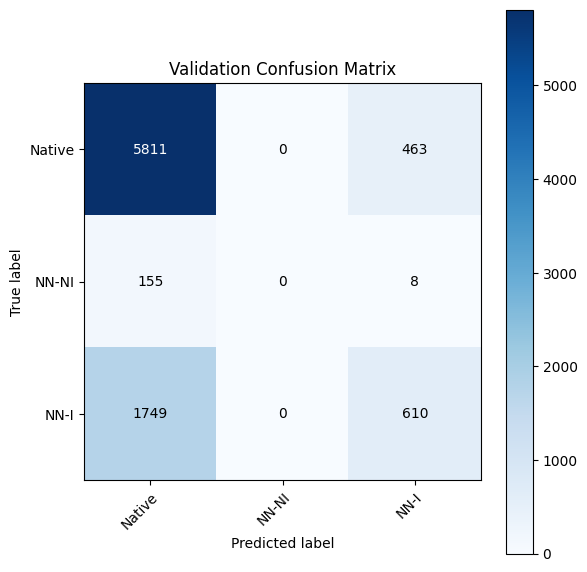


🔁 Epoch 6/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1142.09it/s]


📉 Train Loss: 0.5805 | Accuracy: 0.7321
📈 Val Loss:   0.5792 | Accuracy: 0.7337

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.77      0.90      0.83      6274
NN Non-Invasive       0.00      0.00      0.00       163
    NN Invasive       0.56      0.34      0.42      2359

       accuracy                           0.73      8796
      macro avg       0.44      0.41      0.42      8796
   weighted avg       0.70      0.73      0.71      8796



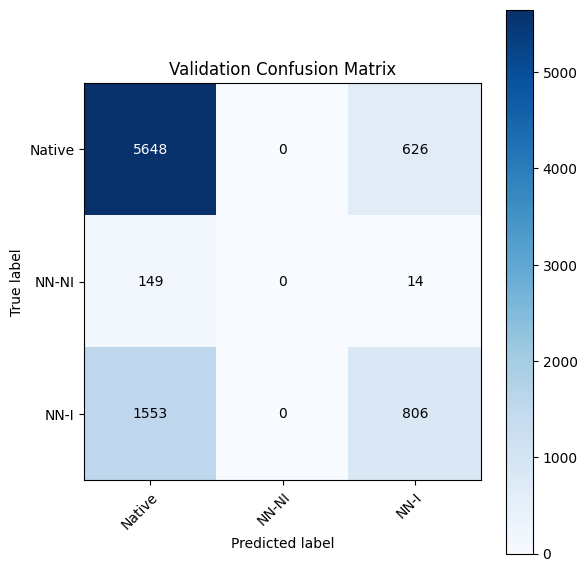


🔁 Epoch 7/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1130.41it/s]


📉 Train Loss: 0.5716 | Accuracy: 0.7373
📈 Val Loss:   0.5764 | Accuracy: 0.7333

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.93      0.83      6274
NN Non-Invasive       0.00      0.00      0.00       163
    NN Invasive       0.58      0.26      0.36      2359

       accuracy                           0.73      8796
      macro avg       0.45      0.40      0.40      8796
   weighted avg       0.69      0.73      0.69      8796



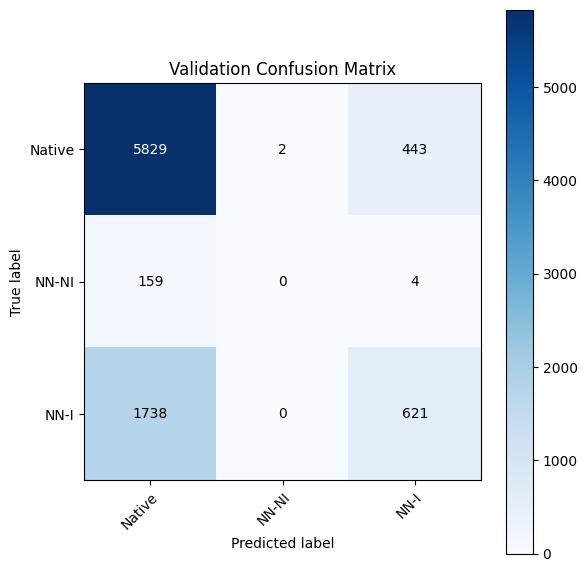


🔁 Epoch 8/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1153.08it/s]


📉 Train Loss: 0.5632 | Accuracy: 0.7405
📈 Val Loss:   0.5756 | Accuracy: 0.7351

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.94      0.84      6274
NN Non-Invasive       0.00      0.00      0.00       163
    NN Invasive       0.60      0.23      0.34      2359

       accuracy                           0.74      8796
      macro avg       0.45      0.39      0.39      8796
   weighted avg       0.70      0.74      0.69      8796



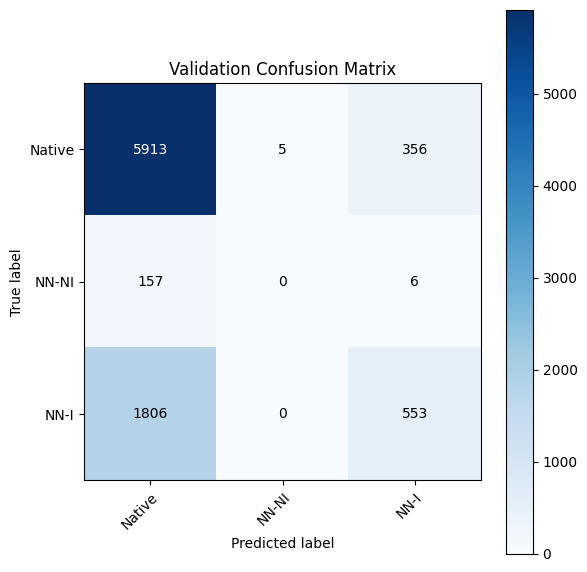


🔁 Epoch 9/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1110.35it/s]


📉 Train Loss: 0.5566 | Accuracy: 0.7457
📈 Val Loss:   0.5740 | Accuracy: 0.7357

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.93      0.83      6274
NN Non-Invasive       0.00      0.00      0.00       163
    NN Invasive       0.59      0.26      0.36      2359

       accuracy                           0.74      8796
      macro avg       0.45      0.40      0.40      8796
   weighted avg       0.70      0.74      0.69      8796



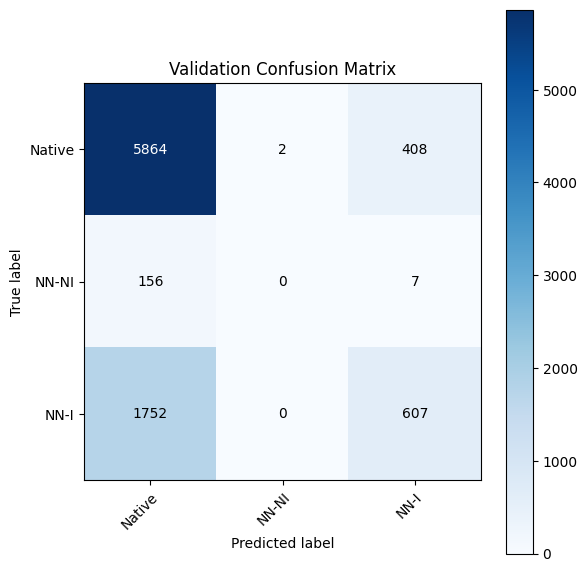


🔁 Epoch 10/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1139.46it/s]


📉 Train Loss: 0.5493 | Accuracy: 0.7501
📈 Val Loss:   0.5745 | Accuracy: 0.7326

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.78      0.88      0.83      6274
NN Non-Invasive       0.00      0.00      0.00       163
    NN Invasive       0.55      0.39      0.46      2359

       accuracy                           0.73      8796
      macro avg       0.44      0.42      0.43      8796
   weighted avg       0.70      0.73      0.71      8796



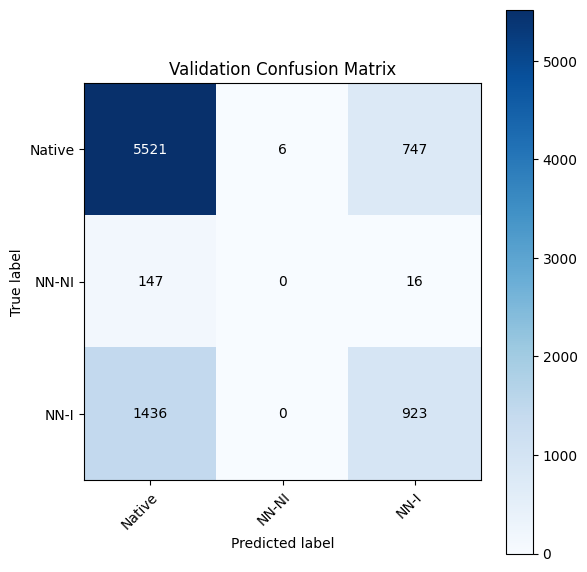

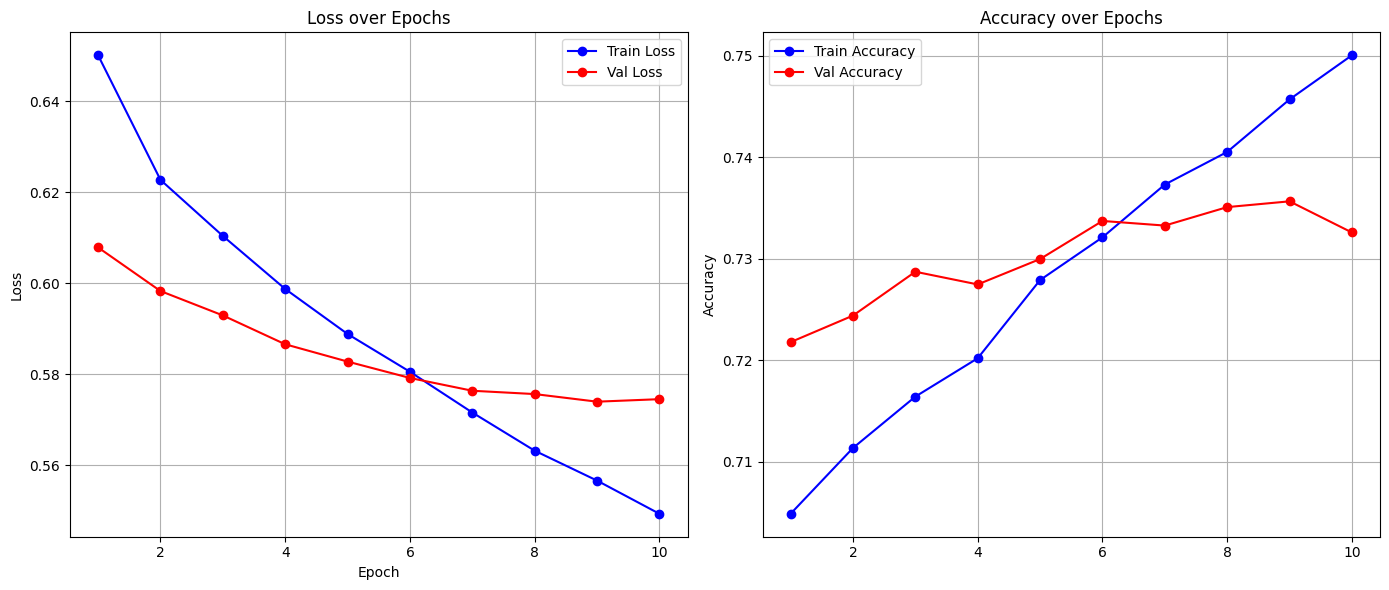

Full model built...
Total execution time: 283.87 seconds


In [13]:
create_model_and_predict(folder_name="taxas", use_bioclip=False, output_dir="invasive_species", model_name="first_attempt")

Using device: cuda
BioCLIP 2!


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

open_clip_config.json:   0%|          | 0.00/534 [00:00<?, ?B/s]

Model obtained...
Feature extractor obtained..
Dataloader obtained..
Train loader embeddings extracted..
Val loader embeddings extracted..

🔁 Epoch 1/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1100.32it/s]


📉 Train Loss: 0.6204 | Accuracy: 0.7150
📈 Val Loss:   0.5284 | Accuracy: 0.7381

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.76      0.93      0.83      6175
NN Non-Invasive       0.00      0.00      0.00       192
    NN Invasive       0.63      0.31      0.42      2429

       accuracy                           0.74      8796
      macro avg       0.46      0.41      0.42      8796
   weighted avg       0.70      0.74      0.70      8796



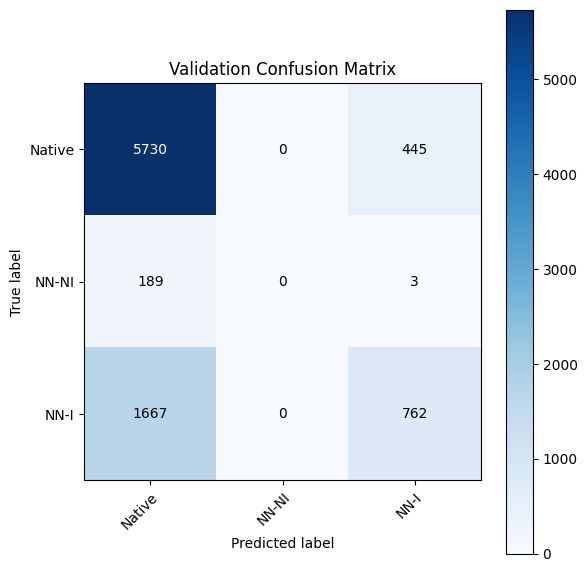


🔁 Epoch 2/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1123.11it/s]


📉 Train Loss: 0.4972 | Accuracy: 0.7576
📈 Val Loss:   0.4892 | Accuracy: 0.7515

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.83      0.82      0.82      6175
NN Non-Invasive       0.00      0.00      0.00       192
    NN Invasive       0.58      0.64      0.61      2429

       accuracy                           0.75      8796
      macro avg       0.47      0.49      0.48      8796
   weighted avg       0.74      0.75      0.75      8796



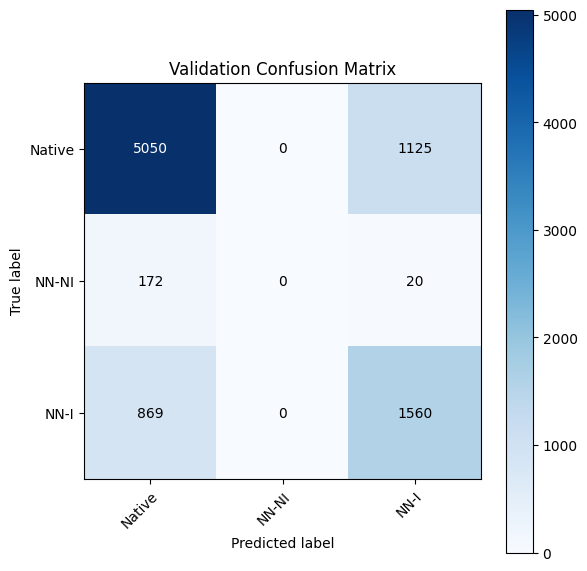


🔁 Epoch 3/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1154.65it/s]


📉 Train Loss: 0.4681 | Accuracy: 0.7732
📈 Val Loss:   0.4657 | Accuracy: 0.7746

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.80      0.92      0.85      6175
NN Non-Invasive       0.00      0.00      0.00       192
    NN Invasive       0.69      0.48      0.56      2429

       accuracy                           0.77      8796
      macro avg       0.49      0.46      0.47      8796
   weighted avg       0.75      0.77      0.75      8796



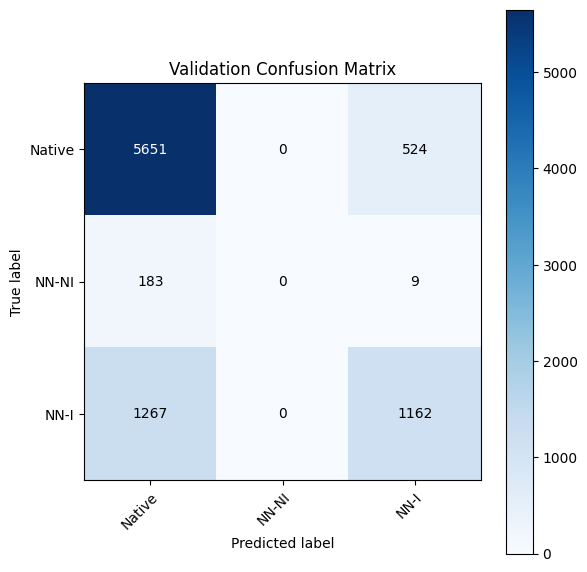


🔁 Epoch 4/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1136.45it/s]


📉 Train Loss: 0.4497 | Accuracy: 0.7821
📈 Val Loss:   0.4484 | Accuracy: 0.7781

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.85      0.84      6175
NN Non-Invasive       0.00      0.00      0.00       192
    NN Invasive       0.63      0.66      0.64      2429

       accuracy                           0.78      8796
      macro avg       0.49      0.50      0.50      8796
   weighted avg       0.76      0.78      0.77      8796



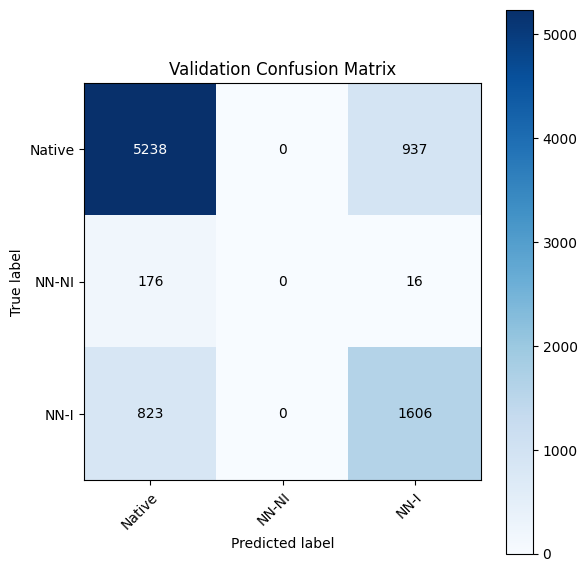


🔁 Epoch 5/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1120.49it/s]


📉 Train Loss: 0.4367 | Accuracy: 0.7887
📈 Val Loss:   0.4367 | Accuracy: 0.7899

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.82      0.89      0.86      6175
NN Non-Invasive       0.00      0.00      0.00       192
    NN Invasive       0.68      0.59      0.63      2429

       accuracy                           0.79      8796
      macro avg       0.50      0.49      0.50      8796
   weighted avg       0.77      0.79      0.78      8796



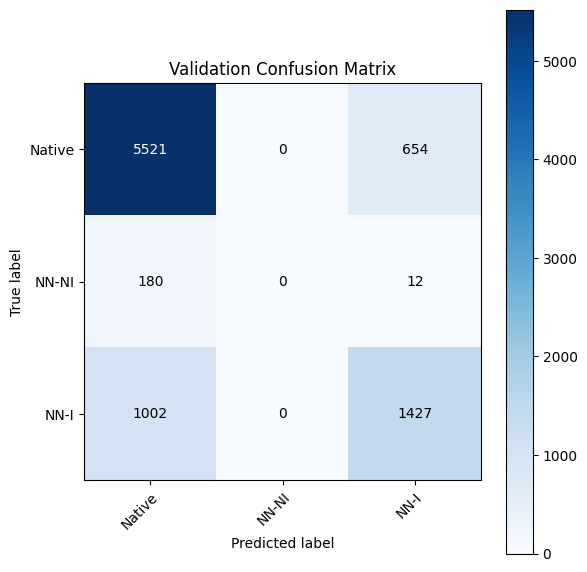


🔁 Epoch 6/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1105.99it/s]


📉 Train Loss: 0.4264 | Accuracy: 0.7963
📈 Val Loss:   0.4268 | Accuracy: 0.7975

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.82      0.91      0.86      6175
NN Non-Invasive       0.00      0.00      0.00       192
    NN Invasive       0.71      0.58      0.64      2429

       accuracy                           0.80      8796
      macro avg       0.51      0.50      0.50      8796
   weighted avg       0.77      0.80      0.78      8796



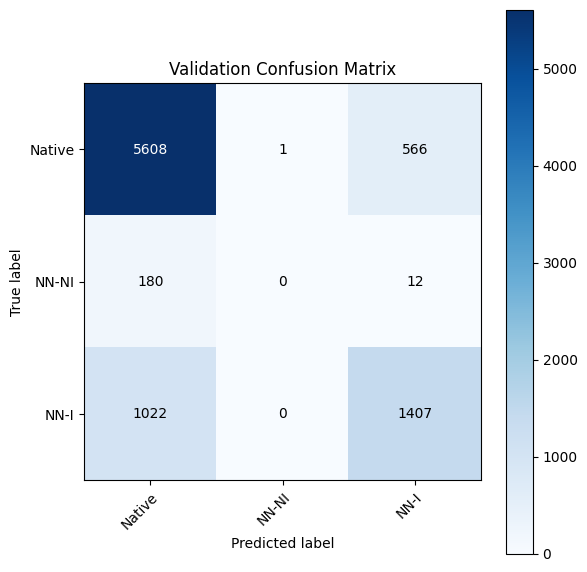


🔁 Epoch 7/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1106.87it/s]


📉 Train Loss: 0.4183 | Accuracy: 0.8007
📈 Val Loss:   0.4193 | Accuracy: 0.7993

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.83      0.90      0.86      6175
NN Non-Invasive       0.50      0.01      0.01       192
    NN Invasive       0.71      0.60      0.65      2429

       accuracy                           0.80      8796
      macro avg       0.68      0.50      0.51      8796
   weighted avg       0.79      0.80      0.79      8796



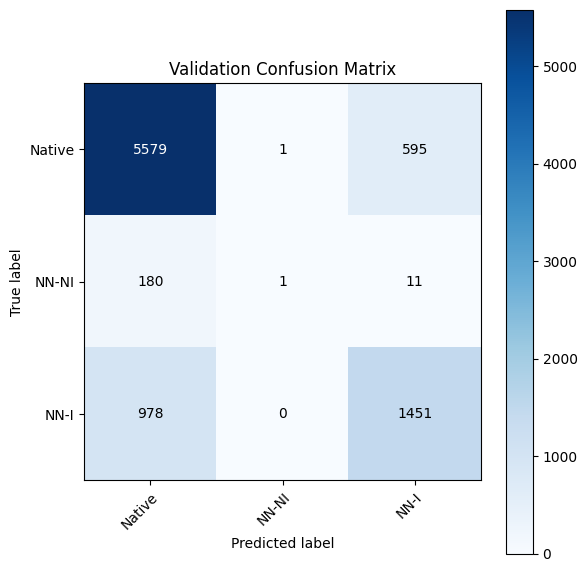


🔁 Epoch 8/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1112.20it/s]


📉 Train Loss: 0.4110 | Accuracy: 0.8050
📈 Val Loss:   0.4129 | Accuracy: 0.8022

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.83      0.91      0.87      6175
NN Non-Invasive       0.40      0.01      0.02       192
    NN Invasive       0.71      0.60      0.65      2429

       accuracy                           0.80      8796
      macro avg       0.65      0.51      0.51      8796
   weighted avg       0.79      0.80      0.79      8796



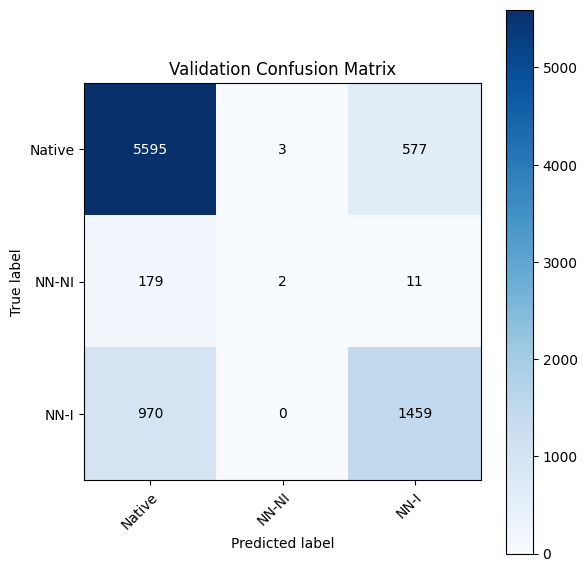


🔁 Epoch 9/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1123.95it/s]


📉 Train Loss: 0.4049 | Accuracy: 0.8082
📈 Val Loss:   0.4059 | Accuracy: 0.8050

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.89      0.87      6175
NN Non-Invasive       0.60      0.03      0.06       192
    NN Invasive       0.70      0.64      0.67      2429

       accuracy                           0.81      8796
      macro avg       0.71      0.52      0.53      8796
   weighted avg       0.80      0.81      0.79      8796



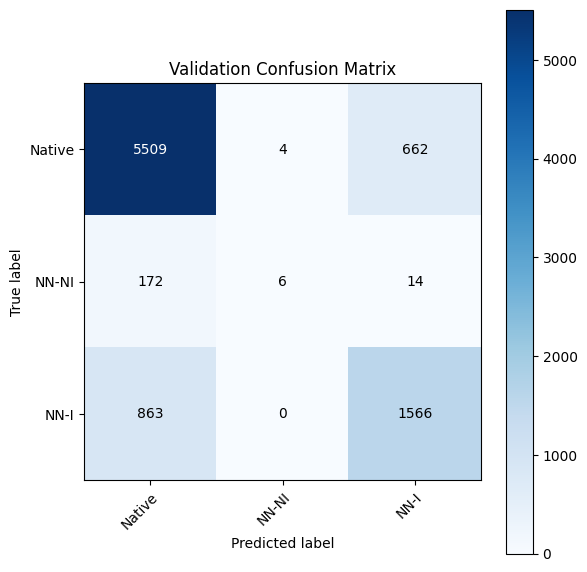


🔁 Epoch 10/10


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1088.06it/s]


📉 Train Loss: 0.3995 | Accuracy: 0.8117
📈 Val Loss:   0.4049 | Accuracy: 0.8038

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.82      0.92      0.87      6175
NN Non-Invasive       0.56      0.03      0.05       192
    NN Invasive       0.74      0.56      0.64      2429

       accuracy                           0.80      8796
      macro avg       0.71      0.50      0.52      8796
   weighted avg       0.79      0.80      0.79      8796



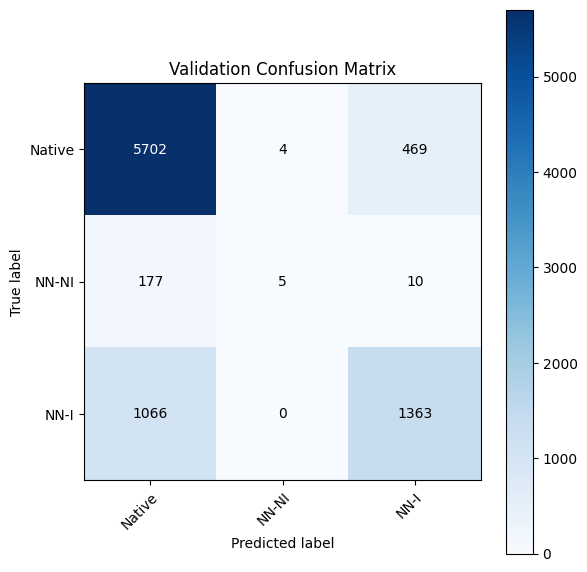

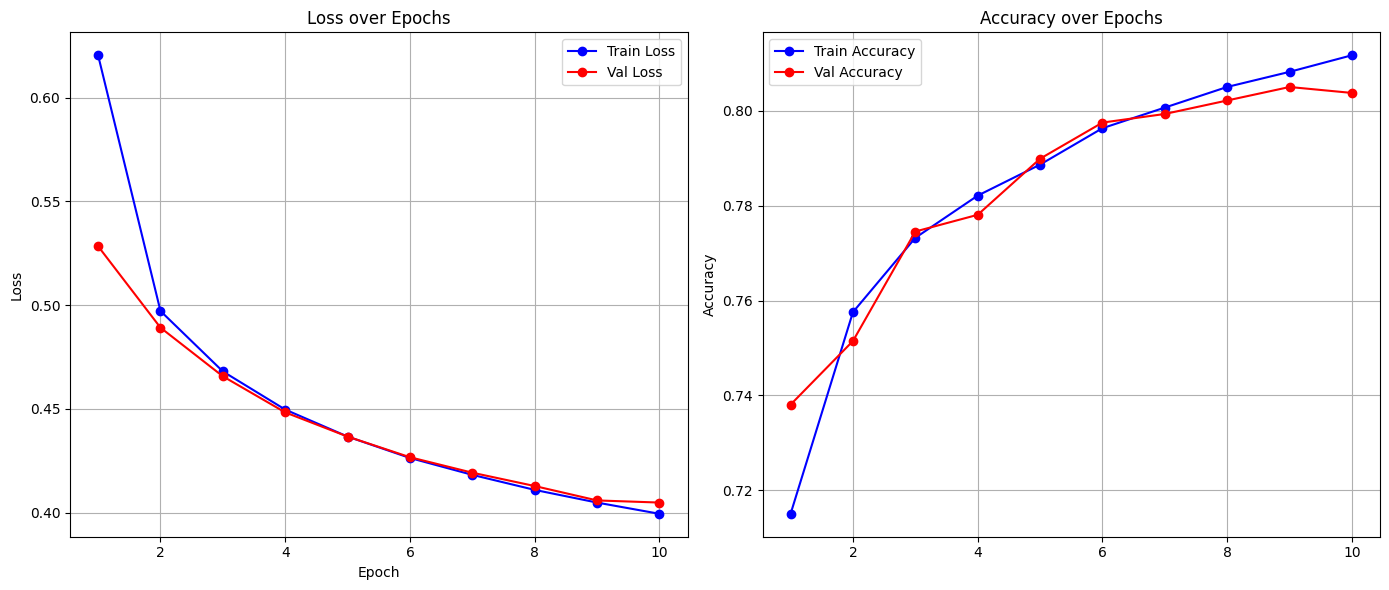

Full model built...
Total execution time: 2165.10 seconds


In [14]:
create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=2, output_dir="invasive_species", model_name="first_attempt")